In [704]:
#PROGRAMA DE SEGMENTACION MAHAlANOBIS
# https://claudiovz.github.io/scipy-lecture-notes-ES/advanced/image_processing/index.html
# https://facundoq.github.io/courses/aa2018/res/04_imagenes_numpy.html 
# https://github.com/scikit-image/scikit-image/tree/main/skimage/segmentation/tests 
#https://stackoverflow.com/questions/32770654/get-pixel-location-using-mouse-click-events
#https://github.com/tvanslyke/ImageProcessing/blob/master/Mahalanobis.py 
#https://www.imageeprocessing.com/2018/06/rgb-image-clustering-using-mahalanobis.html (CODIGO MATLAB)

En este programa se desarrolla el Algoritmo de MAHALANOBIS para segmentación
1. Haciendo click derecho se escogen puntos del color deseado para segmentar.
Nota: haciendo la matriz de covarianza MCRBG=MC=[1 0 0;0 1 0;0 0 1]; se implementa el algoritmo de distancia Euclidiana para segmentación.

In [705]:
## IMPORTACIÓN DE LIBRERIAS
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2 
from numpy.linalg import inv
from scipy.spatial import distance
from scipy.spatial.distance import mahalanobis

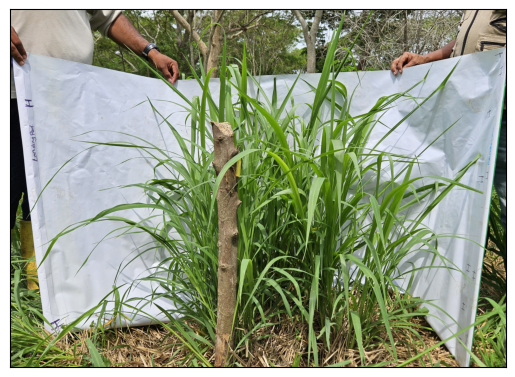

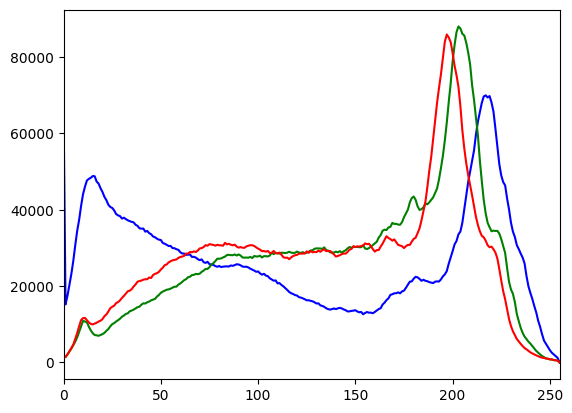

In [706]:
# Apertura de directorio y lectura de archivo de imágen
#a=r'C:\Users\Asus\Documents\AGROSAVIA_2024\BASE_DATOS_MGSN5\EXPERIMENTAL_DATA_MGSN5\4-6Sept2024\RGB_Images'
a=r'C:\Users\Asus\Documents\AGROSAVIA_2024\BASE_DATOS_MGSN5\EXPERIMENTAL_DATA_MGSN5\5-4Ab2025\RGB_Images'
os.chdir(a)
os.listdir(a)
img=cv2.imread('39.jpg')
plt.xticks([]), plt.yticks([])
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.xticks([]), plt.yticks([])
plt.show()

color = ('b','g','r')
histog=[]
for i, c in enumerate(color):
    hist = cv2.calcHist([img], [i], None, [256], [0, 255])
    histog.append(hist)
    plt.plot(hist, color = c)
    plt.xlim([0,255])

plt.show()

cv2.destroyAllWindows()

In [707]:
historgb=np.array(histog)
maxhisto_green= max(historgb[1,:,:])
print(maxhisto_green)
max_green=np.array(np.where(historgb[1,:,:] == maxhisto_green))[0]
print(max_green[0])

[87992.]
203


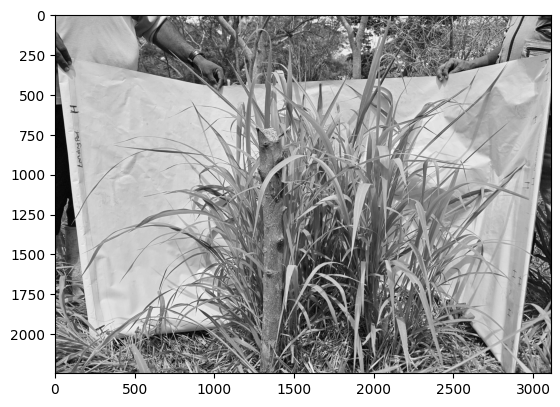

In [708]:
#imagenes individuales R - G . B que se ve en blanco y negro en el espacio de la imagen
imgcolorspace=img[:,:,1]
plt.imshow(imgcolorspace, cmap='gray')
#plt.xticks([]), plt.yticks([])
plt.show()

In [709]:
#escogiendo a  través del click derecho los puntos para el filtro Mahalanobis
#RECOMENDACION= ESCOGER 10 puntos
right_clicks = list()
#Funcion para hacer click derecho y escoger los puntos
def mouse_callback(event, x, y, flags, params):

    #si hay mas de dos clicks derecho
    if event == 2:
        global right_clicks

        #guarda las coordenadas de los click derechos ejecutadas en la imagen
        right_clicks.append([x, y])

        #esto verifica que hayas hecho click
        #print (right_clicks)

#Tamaño de la imagen desplegada
sizew=2500
sizeh=4000
#escalamiento segun la escala (ancho y alto)
scale_width = sizew / img.shape[0]
scale_height = sizeh / img.shape[1]
scale = min(scale_width, scale_height)
window_width = int(img.shape[0] * scale)
window_height = int(img.shape[1] * scale)
cv2.namedWindow('image', cv2.WINDOW_NORMAL)
cv2.resizeWindow('image', window_width, window_height)

#Aplicación de la función mousecallback en la imagen y cierre de la ventana
cv2.setMouseCallback('image', mouse_callback)
cv2.imshow('image', img)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [710]:
#PARA MULTIPLES CLICKS
#calculando el valor del color RBG en cada pixel
r=0
g=1
b=2
imgrgb_r=img[:, :,r] #red
imgrgb_g=img[:, :,g] #green
imgrgb_b=img[:, :,b] #blue
imgrgb_r_all=[]
imgrgb_g_all=[]
imgrgb_b_all=[]
color_all=[]
for i in range(0, len(right_clicks)):
    pixel_xy=right_clicks [i]
    pixel_x=pixel_xy[1]
    pixel_y=pixel_xy[0]
    imgrgb_rr =int(img[pixel_x,pixel_y, r])
    imgrgb_gg =int(img[pixel_x,pixel_y, g])
    imgrgb_bb =int(img[pixel_x,pixel_y, b])
    imgrgb_r_all.append(imgrgb_rr)  #valor del verde (R, red) en cada pixel
    imgrgb_g_all.append(imgrgb_gg)  #valor del verde (G, green) en cada pixel
    imgrgb_b_all.append(imgrgb_bb)  #valor del verde (B, blue) en cada pixel
    color= [img[pixel_x,pixel_y, r], img[pixel_x,pixel_y, g], img[pixel_x,pixel_y, b]]
    color_all.append(color) #arreglo de colores
    color_allrgb=np.array(color_all)
    
def repetir(A, veces):
    AA = []
    for elemento in A:
        AA.extend([elemento] * veces)
    return AA
R1=np.linspace(1, len(right_clicks), len(right_clicks))
R=np.reshape(repetir(R1, len(right_clicks)), (len(right_clicks), len(right_clicks)))
filtroMahalanobis=np.array([color_allrgb])
filtroMahalanobisCol=np.array(repetir(filtroMahalanobis, len(right_clicks)))

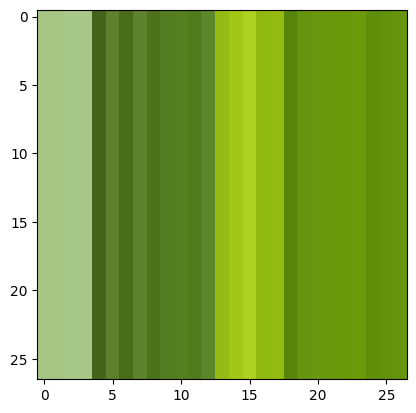

In [711]:
#PLOT DEL FILTRO DE MAHALANOBIS
plt.imshow(cv2.cvtColor(filtroMahalanobisCol, cv2.COLOR_BGR2RGB))
plt.show()

In [712]:
#matriz de covarianza normalizada para aplicar Mahalanobis
MCov_click=inv(np.cov(color_allrgb.T))
MCov_nor=MCov_click/np.max(np.max(MCov_click))
#MCov_nor=np.array([[1, 0, 0],[0, 1, 0],[0, 0, 1]]) #Algoritmo de distancia Euclidiana
colormedio=np.array([np.mean(color_allrgb[:,r]),np.mean(color_allrgb[:,g]), np.mean(color_allrgb[:,b])])
#escogiendo un punto de la imagen
pix_x_choose=10
pix_y_choose=10
puntoimag=img[pix_x_choose,pix_y_choose,:]
mahal_dist= distance.mahalanobis(puntoimag, colormedio, MCov_nor)
Apix_totalx=np.shape(img)[0]
Apix_totaly=np.shape(img)[1]
#calculo del filtro Mahalanobis
img3=img
mahal_distIMall=[]
for i in range(0, Apix_totalx):
    for j in range(0, Apix_totaly):
        IM= [img[i, j, r], img[i, j, g], img[i, j, b]]
        mahal_distIM= distance.mahalanobis(IM, colormedio, MCov_nor)
        mahal_distIMall.append(mahal_distIM)
        if mahal_distIM >=10:
            img3[i,j,:]=np.array([0, 0, 0])

In [713]:
np.cov( (color_allrgb/255 ).T )

array([[0.02696627, 0.01033269, 0.01313479],
       [0.01033269, 0.01634524, 0.01731543],
       [0.01313479, 0.01731543, 0.01882944]])

In [714]:
colormedio/255

array([0.1513435 , 0.60711692, 0.4496732 ])

In [715]:
print(np.max(mahal_distIMall))
print(np.min(mahal_distIMall))
print(colormedio[1])

116.66749166770228
0.14480081252988575
154.8148148148148


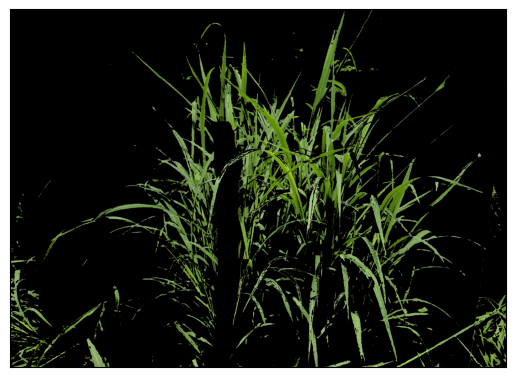

In [716]:
plt.xticks([]), plt.yticks([])
plt.imshow(cv2.cvtColor(img3[:,:,:], cv2.COLOR_BGR2RGB))
plt.show()

In [717]:
testreshape= np.reshape(img3, (img3.shape[0] * img3.shape[1], 3))
testreshape2=list(np.reshape(testreshape,3*img3.shape[0]*img3.shape[1]))
zeros_imag=len([x for x in testreshape2 if x == 0])
ones_imag_segm=len(testreshape2)-zeros_imag
print(zeros_imag)
print(ones_imag_segm)

18085758
2882898


In [718]:
mean_pixel_segmentednozero=np.sum(img3[:,:,g])/(img3.shape[0]*img3.shape[1]-np.floor(zeros_imag/3))
print(mean_pixel_segmentednozero) #media pix segmentado
error=colormedio[1] - mean_pixel_segmentednozero
print(colormedio[1])
print(error)

151.0718454138856
154.8148148148148
3.742969400929212


In [719]:
mean_pixel_segmented=np.mean(img3[:,:,g])
print(mean_pixel_segmented)

20.77027354542895


In [720]:
pixel_segmented=([np.mean(img3[:,:,r]), np.max([mean_pixel_segmentednozero, mean_pixel_segmented]), np.mean(img3[:,:,b])])
print(pixel_segmented) #maximo verdor
print(colormedio) #media de 10 puntos
print([pixel_segmented[1], colormedio[1]])
print([pixel_segmented[1]/255, colormedio[1]/255])
desv_norm=pixel_segmented[1]/255 - colormedio[1]/255
print(np.abs(desv_norm))
print(ones_imag_segm)

[9.621752724638146, 151.0718454138856, 15.961800556029914]
[ 38.59259259 154.81481481 114.66666667]
[151.0718454138856, 154.8148148148148]
[0.5924386094662181, 0.607116920842411]
0.01467831137619291
2882898
